In [1]:
import numpy as np
import pandas as pd 
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from src.monitoring.io import load_generation_log, record_key, parse_parent_key
from src.utils import str_to_func

In [2]:
# records = load_generation_log('program_databases/02-25/11-21-52/program_generation_log.jsonl')
# records = load_generation_log('program_databases/02-25/21-09-47/program_generation_log.jsonl')
# records = load_generation_log('program_databases/03-02/14-46-36/program_generation_log.jsonl')
records = load_generation_log('program_databases/03-02/17-21-38/program_generation_log.jsonl')

for record in records:
    # use record_key to extract the id of each record 
    record['id'] = record_key(record)
df_raw = pd.DataFrame(records)

print(df_raw.columns)

df = df_raw.copy()

Index(['iteration_number', 'birth_island', 'batch_index', 'parent1_id',
       'parent2_id', 'train_loss', 'initial_loss', 'n_params',
       'complexity_penalty', 'model_code_numpy', 'param_est_code',
       'model_prompt', 'model_llm_response', 'param_est_prompt',
       'param_est_llm_response', 'llm_name', 'temperature', 'mode',
       'removal_reason', 'is_winner', 'id', 'use_large_model',
       'image_prompt_path', 'status', 'failure_stage', 'failure_message',
       'model_code_jax', 'param_est_refinement_prompts',
       'param_est_refinement_responses', 'train_fit_image_path',
       'test_fit_image_path', 'test_loss'],
      dtype='object')


Inspecting removed models 

In [3]:
id = (2, 4, 5)
removal_reason = df[(df['id'] == id)]['removal_reason']
removed_model_code = df[(df['id'] == id)]['model_code_numpy']
# print("Removal code : ")
# print(removed_model_code.iloc[0])

for key, value in removal_reason.iloc[0].items():
    print(f"{key} : {value}")

kept_model_id = tuple(removal_reason.iloc[0]['details']['kept_uid'])
print(f"Kept model id : {kept_model_id}")

kept_model_code = df[df['id'] == kept_model_id]['model_code_numpy']
print("Kept model code : ")
print(kept_model_code.iloc[0])

category : deduplication
event_type : DEDUP_CROSS_ISLAND_REMOVE
island_id : 4
rule : cross_island_keep_lower_loss
details : {'reference_island': 0, 'kept_uid': [0, 0, 4], 'kept_loss': 28.755192, 'removed_loss': 28.80065, 'match_rule': 'behavioral_cosine_similarity', 'cosine_similarity': 0.99094158411026, 'cosine_tol': 0.99}
Kept model id : (0, 0, 4)
Kept model code : 
import numpy as np

def neuron_model(X, # independent variable: X = [theta]
                     theta_pref=0.0, baseline=0.0,
                     amplitude_1=1.0, tuning_width_1_left=0.5, tuning_width_1_right=0.5,
                     amplitude_2=0.5, tuning_width_2_left=0.5, tuning_width_2_right=0.5):
    """
    Parent_models: Gaussian_Tuning_Model, Double_Gaussian_Tuning_Model

    Equation:
    Let d1 be the signed circular distance from theta to theta_pref, and d2 be the signed circular distance from theta to (theta_pref + pi).
    Let w1 be tuning_width_1_left if d1 < 0, else tuning_width_1_right.
    Let w2 be tu

Inspecting the winning model 

In [4]:
# load data and split to train and test 

import yaml
from projects.orientation_tuning.spec import load_and_process_data, train_test_split
from src.data_structures import Inputs, Outputs

# get data_processing_params.data_dir from the config yaml file 
config_path = 'projects/orientation_tuning/config.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

data_dir = config['data_processing_params']['data_path']
activity_threshold = config['data_processing_params']['activity_threshold']
conc_threshold = config['data_processing_params']['conc_threshold']
random_seed = 42

def _build_train_test_split_fn(spec_train_test_split_fn):
    """
    Wrap spec.train_test_split so hypothesis_engine gets fully materialized
    sample+trial train/test indices.
    """
    def _wrapped_train_test_split_fn(inputs_3d: np.ndarray, random_seed: int):
        train_samples_raw, train_trials_raw = spec_train_test_split_fn(
            Inputs.from_array(inputs_3d),
            random_seed,
        )
        n_samples = int(inputs_3d.shape[0])
        n_trials = int(inputs_3d.shape[2])
        train_samples = np.asarray(train_samples_raw).reshape(-1).astype(np.int64, copy=False)
        train_trials = np.asarray(train_trials_raw).reshape(-1).astype(np.int64, copy=False)
        test_samples = np.setdiff1d(np.arange(n_samples, dtype=np.int64), train_samples, assume_unique=False)
        test_trials = np.setdiff1d(np.arange(n_trials, dtype=np.int64), train_trials, assume_unique=False)
        return train_samples, test_samples, train_trials, test_trials

    return _wrapped_train_test_split_fn

inputs, outputs = load_and_process_data(data_dir, activity_threshold, conc_threshold)
inputs = np.asarray(inputs.to_tensor())
outputs = np.asarray(outputs.to_tensor())

train_test_split_fn = _build_train_test_split_fn(train_test_split)

train_samples, test_samples, train_trials, test_trials = train_test_split_fn(
    inputs, random_seed
)

X_train_train_trials = inputs[train_samples][:, :, train_trials]
X_train_test_trials = inputs[train_samples][:, :, test_trials]
X_test_train_trials = inputs[test_samples][:, :, train_trials]
X_test_test_trials = inputs[test_samples][:, :, test_trials]

Y_train_train_trials = outputs[train_samples][:, :, train_trials]
Y_train_test_trials = outputs[train_samples][:, :, test_trials]
Y_test_train_trials = outputs[test_samples][:, :, train_trials]
Y_test_test_trials = outputs[test_samples][:, :, test_trials]

X = np.empty((2, 2), dtype=object)
Y = np.empty((2, 2), dtype=object)
X[0, 0] = Inputs.from_array(X_train_train_trials)
X[0, 1] = Inputs.from_array(X_train_test_trials)
X[1, 0] = Inputs.from_array(X_test_train_trials)
X[1, 1] = Inputs.from_array(X_test_test_trials)
Y[0, 0] = Outputs.from_array(Y_train_train_trials)
Y[0, 1] = Outputs.from_array(Y_train_test_trials)
Y[1, 0] = Outputs.from_array(Y_test_train_trials)
Y[1, 1] = Outputs.from_array(Y_test_test_trials)

In [5]:
model_code_jax = df[df['is_winner']]['model_code_jax']
param_estimator = df[df['is_winner']]['param_est_code']

model_fn = str_to_func(model_code_jax.iloc[0], 'neuron_model')
param_estimator_fn = str_to_func(param_estimator.iloc[0], 'parameter_estimator')

In [15]:
# fit the parameters of the winning model to the training data using src.hypothesis_engine.objective
from src.hypothesis_engine import objective
from projects.orientation_tuning.spec import loss_fn 

param_penalty_weight = 0.01 # from the default config.yaml
max_iter = 1000 # from the default config.yaml
trial_batch_size = None 

initial_loss, initial_params, loss, optimized_params = objective(
    model_fn,
    param_estimator_fn,
    x=X[0],
    y=Y[0],
    loss_fn=loss_fn,
    param_penalty_weight=param_penalty_weight,
    fit_params=True,
    use_param_estimator=True,
    max_iter=max_iter,
    trial_batch_size=trial_batch_size,
)

step   50  loss 29.5005
step  100  loss 28.1629
step  150  loss 27.9538
step  200  loss 27.8427
step  250  loss 27.7736
step  300  loss 27.7260
step  350  loss 27.6907
step  400  loss 27.6644


2026-03-03 15:24:42 | INFO | 10800974ms | Loss is NaN or Inf at step 489. Stopping optimization.


step  450  loss 27.6430
Final loss: 27.6296 at step 489
params optimized. Loss: 27.6300
Time taken for optimization: 0.9671 seconds


In [64]:
# Visualise the cell fit 
from projects.orientation_tuning.spec import plot_model_fits
from datetime import datetime 
from src.utils import compute_evaluation_matrix 

# compute the model predictions using the optimized parameters
eval_points = jnp.asarray(X[0, 0].to_tensor())
x_eval = compute_evaluation_matrix(model_fn, optimized_params, eval_points)
loss_per_cell = loss_fn(x_eval, Y[0, 0].to_tensor()[:, 0, :])

stims = eval_points[:, 0, :] # shape (n_cells, n_stims)

# 1. Sort the stimulus angles for each cell
sorted_indices = np.argsort(stims, axis=1) # shape (n_cells, n_stims), each row contains the indices that would sort the stimulus angles for that cell
stims = np.take_along_axis(stims, sorted_indices, axis=1)
x_eval = np.take_along_axis(x_eval, sorted_indices, axis=1)
Y_sorted = np.take_along_axis(Y[0, 0].to_tensor()[:, 0, :], sorted_indices, axis=1)

# 2. Calculate the binned mean of the actual data for better visualisation. Use a vectorised method to compute the binned means for all cells at once.
n_bins = 50
bins = np.linspace(0, 2 * np.pi, n_bins + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2
digitized = np.digitize(stims, bins) - 1
binned_actual = np.array([np.array([Y_sorted[cell_idx, digitized[cell_idx] == j].mean() for j in range(n_bins)]) for cell_idx in range(stims.shape[0])])


/tmp/ipykernel_1725552/1625494775.py:24: RuntimeWarning: Mean of empty slice.
  binned_actual = np.array([np.array([Y_sorted[cell_idx, digitized[cell_idx] == j].mean() for j in range(n_bins)]) for cell_idx in range(stims.shape[0])])
/home/dabin/miniconda3/envs/shared/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


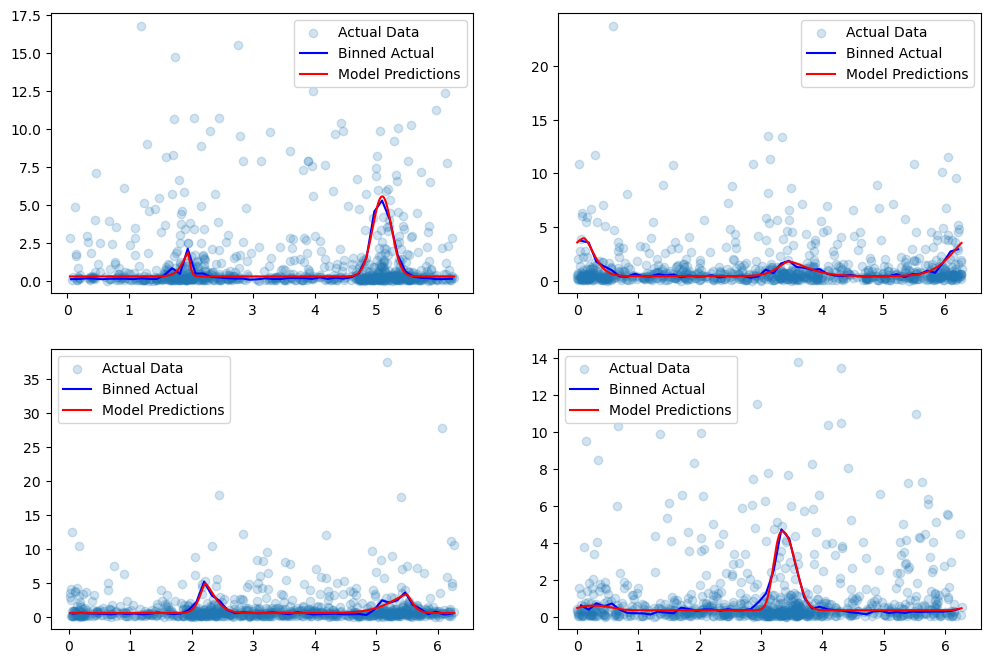

In [67]:
plot_raw_data = True 

# plot x_eval and Y[0, 0] for 4 randomly selected cells
cell_indices = np.random.choice(x_eval.shape[0], size=4, replace=False)

plt.subplots(figsize=(12, 8), nrows=2, ncols=2)
for i, cell_idx in enumerate(cell_indices):
    plt.subplot(2, 2, i + 1)
    
    # calculate the binned mean of the actual data and model predictions for better visualization
    
    if plot_raw_data:
        plt.scatter(stims[cell_idx], Y[0, 0].to_tensor()[cell_idx, 0, :], label='Actual Data', alpha=0.2)
    plt.plot(bin_centers, binned_actual[cell_idx], label='Binned Actual', color='blue')
    plt.plot(stims[cell_idx], x_eval[cell_idx], label='Model Predictions', color='red')
    
    plt.legend()
plt.show()


In [84]:
from src.utils import vmap_over_samples
def get_sigmoidal_floor_per_cell(X,
                     theta_pref=0.0,
                     baseline=0.0,
                     amplitude_1=1.0,
                     tuning_width_1_pos=0.5, tuning_width_1_neg=0.5,
                     peak_exponent_1=2.0,
                     amplitude_2=0.0,
                     offset_angle_2=0.0,
                     tuning_width_2_pos=0.5, tuning_width_2_neg=0.5,
                     peak_exponent_2=2.0,
                     sigmoid_steepness=1.0,
                     sigmoid_floor_offset=0.0):
    """
    parent_model_1: asymmetric_double_gaussian_with_sigmoid_floor-model
    parent_model_2: asymmetric_double_skew_gaussian_model
    parent_model_3: generalized_gaussian_with_adjustable_sigmoid_floor

    Equation:
    signed_angle_diff(theta_stim, theta_peak) = np.arctan2(np.sin(theta_stim - theta_peak), np.cos(theta_stim - theta_peak))

    # For Peak 1 centered at theta_pref (P1)
    peak1_angle_diff = signed_angle_diff(theta, P1)
    peak1_width_choice = np.where(peak1_angle_diff >= 0, tuning_width_1_pos, tuning_width_1_neg)
    term1 = amplitude_1 * np.exp(- (np.abs(peak1_angle_diff) / peak1_width_choice) ** peak_exponent_1)

    # For Peak 2 centered at P2 = (theta_pref + pi + offset_angle_2) % (2*pi)
    peak2_angle_diff = signed_angle_diff(theta, P2)
    peak2_width_choice = np.where(peak2_angle_diff >= 0, tuning_width_2_pos, tuning_width_2_neg)
    term2 = amplitude_2 * np.exp(- (np.abs(peak2_angle_diff) / peak2_width_choice) ** peak_exponent_2)

    # Sigmoid "floor" with steepness parameter
    sigmoid_floor = (baseline + sigmoid_floor_offset) / (1 + np.exp(-sigmoid_steepness * (term1 + term2))) - sigmoid_floor_offset

    response = sigmoid_floor + term1 + term2

    This model refines the representation of neural activity by:

    1.  **Preserves Asymmetric Peak Shaping**: Carries over asymmetric tuning widths, offset angle for the second peak, and peak exponents from parent models.
    2.  **Compensates for baseline with an adjustable sigmoid floor offset:** Addresses a core limitation of `parent_model_1`, especially in cells exhibiting inaccurate baseline estimation (Cell 657, Cell 933, etc). By including an additive `sigmoid_floor_offset`, the floor of the previous model can be displaced, to compensate for inaccuracies introduced by the baseline parameter, improving overall fit, while maintaining similar complexity.
    """
    theta = X[0]

    # Clip parameters to biologically plausible ranges
    theta_pref = np.clip(theta_pref, 0, 2 * np.pi)
    baseline = np.clip(baseline, 0, None)
    amplitude_1 = np.clip(amplitude_1, 0, None)
    amplitude_2 = np.clip(amplitude_2, 0, None)
    tuning_width_1_pos = np.clip(tuning_width_1_pos, 0.01, None)
    tuning_width_1_neg = np.clip(tuning_width_1_neg, 0.01, None)
    peak_exponent_1 = np.clip(peak_exponent_1, 0.5, 5.0)
    offset_angle_2 = np.clip(offset_angle_2, -np.pi / 2, np.pi / 2)
    tuning_width_2_pos = np.clip(tuning_width_2_pos, 0.01, None)
    tuning_width_2_neg = np.clip(tuning_width_2_neg, 0.01, None)
    peak_exponent_2 = np.clip(peak_exponent_2, 0.5, 5.0)
    sigmoid_steepness = np.clip(sigmoid_steepness, 0.01, 10.0) # Restrict steepness to sensible values
    sigmoid_floor_offset = np.clip(sigmoid_floor_offset, -5.0, 5.0) # Floor can't shift too high or low

    # Utility function to calculate signed circular difference
    def signed_circ_diff(angle1, angle2):
        return np.arctan2(np.sin(angle1 - angle2), np.cos(angle1 - angle2))

    # Utility function for absolute circular distance (not actually used)
    circ_dist_rad = lambda a1, a2: np.abs(signed_circ_diff(a1, a2))

    # --- Peak 1 Calculation ---
    theta_pref_1 = theta_pref
    angle_diff_1 = signed_circ_diff(theta, theta_pref_1)
    
    # Choose width based on the sign of the angular difference for the first peak
    width_1 = np.where(angle_diff_1 >= 0, tuning_width_1_pos, tuning_width_1_neg)
    
    # Generalized Gaussian term for Peak 1
    term_1 = amplitude_1 * np.exp(- (np.abs(angle_diff_1) / width_1) ** peak_exponent_1)

    # --- Peak 2 Calculation ---
    theta_pref_2 = (theta_pref + np.pi + offset_angle_2) % (2 * np.pi)
    angle_diff_2 = signed_circ_diff(theta, theta_pref_2)
    
    # Choose width based on the sign of the angular difference for the second peak
    width_2 = np.where(angle_diff_2 >= 0, tuning_width_2_pos, tuning_width_2_neg)
    
    # Generalized Gaussian term for Peak 2
    term_2 = amplitude_2 * np.exp(- (np.abs(angle_diff_2) / width_2) ** peak_exponent_2)

    # --- Sigmoid Floor Calculation ---
    # Compressive sigmoid floor with steepness parameter. This replaces the ambient amplitude
    sigmoid_floor = (baseline + sigmoid_floor_offset) / (1 + np.exp(-sigmoid_steepness * (term_1 + term_2))) - sigmoid_floor_offset

    # Total response
    return sigmoid_floor

get_sigmoidal_floor =  vmap_over_samples(get_sigmoidal_floor_per_cell) # this function now takes in arrays of shape (n_cells, n_stims) and (n_cells, n_params) and returns an array of shape (n_cells, n_stims) representing the sigmoidal floor component for each cell across all stimulus angles.

In [85]:
eval_points.shape, optimized_params.shape

((1055, 1, 856), (1055, 13))

In [86]:
    # params_arr = jnp.asarray(params)
    # eval_arr = jnp.asarray(eval_points)
    
eval_points_jnp = np.asarray(eval_points[:, 0, :])
optimized_params_jnp = np.asarray(optimized_params)
sigmoidal_floor_component = get_sigmoidal_floor(eval_points_jnp, optimized_params_jnp)
print(f"Shape of sigmoidal_floor_component: {sigmoidal_floor_component.shape}") # should be (n_cells, n_stims)

TracerArrayConversionError: The numpy.ndarray conversion method __array__() was called on traced array with shape float32[]
This BatchTracer with object id 139617207460848 was created on line:
  /home/dabin/code/EDGAR-gamma/src/utils.py:56:15 (vmap_over_samples.<locals>._wrapped)
See https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerArrayConversionError

In [ ]:
plot_raw_data = True 

# plot x_eval and Y[0, 0] for 4 randomly selected cells
cell_indices = np.random.choice(x_eval.shape[0], size=4, replace=False)


plt.subplots(figsize=(12, 8), nrows=2, ncols=2)
for i, cell_idx in enumerate(cell_indices):
    plt.subplot(2, 2, i + 1)
    
    # calculate the binned mean of the actual data and model predictions for better visualization
    
    if plot_raw_data:
        plt.scatter(stims[cell_idx], Y[0, 0].to_tensor()[cell_idx, 0, :], label='Actual Data', alpha=0.2)
    plt.plot(bin_centers, binned_actual[cell_idx], label='Binned Actual', color='blue')
    plt.plot(stims[cell_idx], x_eval[cell_idx], label='Model Predictions', color='red')
    
    # plot just the signmoidal floor component for visual inspection 
    plt.plot(stims[cell_idx], sigmoidal_floor, label='Sigmoidal Floor', color='green')
    
    plt.legend()
plt.show()


TracerArrayConversionError: The numpy.ndarray conversion method __array__() was called on traced array with shape float32[]
This BatchTracer with object id 139617204095312 was created on line:
  /home/dabin/code/EDGAR-gamma/src/utils.py:56:15 (vmap_over_samples.<locals>._wrapped)
See https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerArrayConversionError

In [ ]:
# def neuron_model(X,
#                      theta_pref=0.0,
#                      baseline=0.0,
#                      amplitude_1=1.0,
#                      tuning_width_1_pos=0.5, tuning_width_1_neg=0.5,
#                      peak_exponent_1=2.0,
#                      amplitude_2=0.0,
#                      offset_angle_2=0.0,
#                      tuning_width_2_pos=0.5, tuning_width_2_neg=0.5,
#                      peak_exponent_2=2.0,
#                      sigmoid_steepness=1.0,
#                      sigmoid_floor_offset=0.0)

n_cells, n_params = optimized_params.shape 


baseline = optimized_params[:, 0]
sigmoid_steepness = optimized_params[:, -2]
sigmoid_floor_offset = optimized_params[:, -1]

cell_idxes = np.random.choice(n_cells, size=4, replace=False)


sigmoid_floor = (baseline + sigmoid_floor_offset) / (1 + np.exp(-sigmoid_steepness * (term_1 + term_2))) - sigmoid_floor_offset

(1055, 13)